In [1]:
import numpy as np
import pandas as pd
import matplotlib . pyplot as plt
from sklearn . model_selection import train_test_split
from sklearn . preprocessing import StandardScaler
from sklearn . linear_model import LinearRegression
from sklearn . metrics import mean_squared_error , r2_score

In [7]:

placement = pd.read_csv("placement_predict_50k.csv")

print(placement.shape)
placement.head()


(50000, 12)


,StudentID,Stream,Gender,CGPA,CGPA_Tier,Internships,Projects,AptitudeScore,SoftSkillsRating,Backlogs,PlacementTraining,PlacementStatus
0,1,CSE,Male,5.00,Low,0,0,37,2.3,3,No,NotPlaced
1,2,EEE,Male,6.77,Medium,2,2,53,3.3,1,No,NotPlaced
2,3,CSE,Male,6.83,Medium,0,1,61,2.5,1,Yes,Placed
3,4,ECE,Male,5.65,Low,0,2,70,2.1,2,Yes,NotPlaced
4,5,CIVIL,Male,5.00,Low,0,1,40,1.5,2,No,NotPlaced


In [8]:
placement . info ()
print ( placement . describe () )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          50000 non-null  int64  
 1   Stream             50000 non-null  object 
 2   Gender             50000 non-null  object 
 3   CGPA               50000 non-null  float64
 4   CGPA_Tier          50000 non-null  object 
 5   Internships        50000 non-null  int64  
 6   Projects           50000 non-null  int64  
 7   AptitudeScore      50000 non-null  int64  
 8   SoftSkillsRating   50000 non-null  float64
 9   Backlogs           50000 non-null  int64  
 10  PlacementTraining  50000 non-null  object 
 11  PlacementStatus    50000 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 4.6+ MB
          StudentID          CGPA   Internships      Projects  AptitudeScore  \
count  50000.000000  50000.000000  50000.000000  50000.000000    50000.00000 

In [13]:
features =["Internships", "Projects", "AptitudeScore",
           "SoftSkillsRating", "Backlogs"]
X = placement[features]
y = placement["CGPA"]
X_train , X_val ,y_train, y_val = train_test_split (
 X , y , test_size =0.2 , random_state =42)
print ( X_train.shape , X_val.shape )




(40000, 5) (10000, 5)


In [14]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
print ( X_train_s.mean().round(3),X_train_s.std().round(3))

0.0 1.0


In [15]:
lr = LinearRegression()
lr.fit(X_train_s,y_train)
sk_pred = lr.predict(X_val_s)
sk_rmse = np.sqrt(mean_squared_error(y_val,sk_pred))
print("sklearn RMSE :", round(sk_rmse , 4))
print("sklearn R2 :", round(r2_score(y_val,sk_pred),4))

sklearn RMSE : 0.5106
sklearn R2 : 0.7448


In [19]:
def batch_gd(X,y,epochs =1000,rate =0.1) :
   w = np.zeros(X.shape[1])
   b = 0.0
   y = np.asarray(y,dtype = float)
   losses=[]
   for step in range(epochs):
      error = X @ w + b - y
      losses.append((error** 2).mean())
      w = w -rate * ( X . T @ error ) / len( y )
      b = b -rate * error . mean ()
   return w , b , losses
w_batch , b_batch , loss_batch = batch_gd ( X_train_s , y_train )
print (" Final MSE:", round ( loss_batch [ -1] , 4) )

 Final MSE: 0.2618


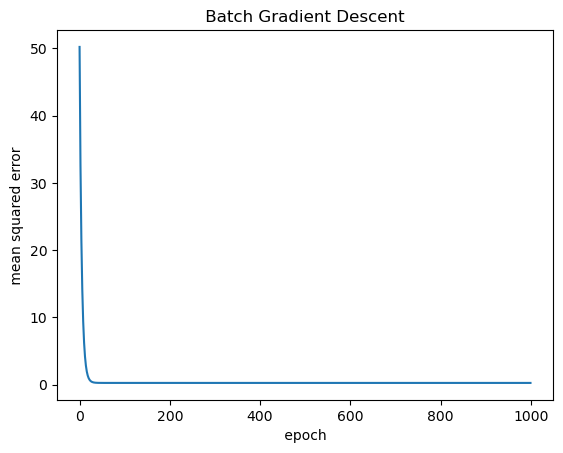

In [20]:
plt . plot ( loss_batch )
plt . xlabel (" epoch ")
plt . ylabel (" mean squared error ")
plt . title (" Batch Gradient Descent ")
plt . show ()


In [21]:
gd_pred = X_val_s @ w_batch + b_batch
gd_rmse = np . sqrt ( mean_squared_error ( y_val , gd_pred ) )
print (" sklearn RMSE :", round ( sk_rmse , 4) )
print (" batch GD RMSE :", round ( gd_rmse , 4) )
print (" largest coef gap :", round ( np .abs( w_batch - lr . coef_ ) .max () , 6) )

 sklearn RMSE : 0.5106
 batch GD RMSE : 0.5106
 largest coef gap : 0.0


 sklearn RMSE : 0.5106
mini - batch RMSE : 0.5107
 Tolerance check PASSED 


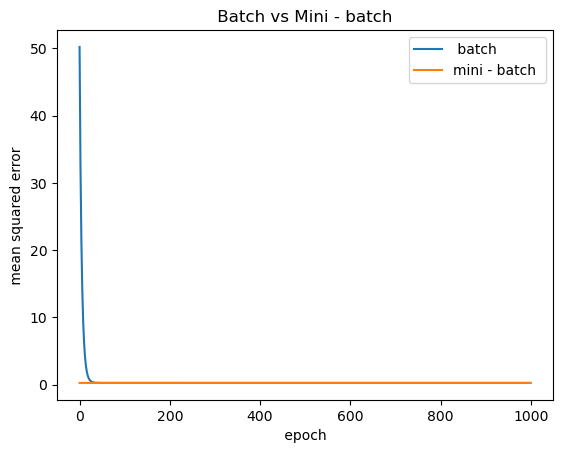

In [22]:
def minibatch_gd (X , y , epochs =1000 , batch_size =32 , rate =0.01) :
    rng = np . random . default_rng (42)
    w = np . zeros ( X . shape [1])
    b = 0.0
    y = np . asarray (y , dtype = float )
    n = len( y )
    losses = []
    for step in range ( epochs ) :
        order = rng . permutation ( n ) # reshuffle each epoch
        for start in range (0 , n , batch_size ):
            idx = order [ start : start + batch_size ]
            error = X [ idx ] @ w + b - y [ idx ]
            w = w - rate * ( X [ idx ]. T @ error ) / len( idx )
            b = b - rate * error . mean ()
        losses . append ((( X @ w + b - y ) ** 2) . mean () )
    return w , b , losses
w_mini , b_mini , loss_mini = minibatch_gd ( X_train_s , y_train )
mini_rmse = np . sqrt ( mean_squared_error ( y_val , X_val_s @ w_mini +
  b_mini ) )
print (" sklearn RMSE :", round ( sk_rmse , 4) )
print ("mini - batch RMSE :", round ( mini_rmse , 4) )
assert abs ( mini_rmse - sk_rmse ) < 0.3 , "mini - batch RMSE is not within 0.3 of sklearn "
print (" Tolerance check PASSED ")
plt . plot ( loss_batch , label =" batch ")
plt . plot ( loss_mini , label ="mini - batch ")
plt . xlabel (" epoch ")
plt . ylabel (" mean squared error ")
plt . legend ()
plt . title (" Batch vs Mini - batch ")
plt . show ()

   
